# Semana 3 –  Backpropagation y Funciones de Activación

Comparar minimo 2 activaciones con misma arquitectura/datos y evidenciar entrenamiento.

## Evidencia esperada
- Comparación válida
- Registro de loss/métrica
- Conclusiones técnicas

## Modelo base

Definir arquitectura base entrenable.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. PREPARACIÓN DE DATASET FINANCIERO (Predicción de Crédito)
np.random.seed(42)
tf.random.set_seed(42)
X_raw = np.random.rand(1000, 4)
# Regla: (Ingresos * 0.7 + Puntaje * 0.3) > 0.5
y_raw = ((X_raw[:,0] * 0.7 + X_raw[:,1] * 0.3) > 0.5).astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. FUNCIÓN PARA CONSTRUIR ARQUITECTURAS
def build_finance_network(architecture_type, activation_func="sigmoid"):
    model = keras.Sequential()
    model.add(layers.Input(shape=(4,)))

    if architecture_type == "perceptron":
        model.add(layers.Dense(1, activation="sigmoid"))
    elif architecture_type == "monocapa":
        model.add(layers.Dense(8, activation=activation_func))
        model.add(layers.Dense(1, activation="sigmoid"))
    elif architecture_type == "multicapa":
        model.add(layers.Dense(16, activation=activation_func))
        model.add(layers.Dense(8, activation=activation_func))
        model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
                  loss="mse",
                  metrics=["accuracy"])
    return model

epochs = 100
print("Dataset y funciones base listos.")

Dataset y funciones base listos.


## Experimento A Perceptrón Simple (Línea Base)

Se implementa un Perceptrón Simple de una sola neurona para establecer una línea base de rendimiento. El objetivo es evaluar si las variables financieras pueden clasificarse correctamente mediante una separación lineal directa.

Entrenar con activación A y Registrar resultados.



In [25]:
print("Entrenando Experimento A: Perceptrón...")
m_perc = build_finance_network("perceptron")
h_perc = m_perc.fit(X_train, y_train, epochs=100, verbose=0)
eval_perc = m_perc.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*70)
print(f"Test (Perceptrón): {eval_perc}")
print(f"Último loss/acc: {h_perc.history['loss'][-1]:.4f} / {h_perc.history['accuracy'][-1]:.4f}")
print("="*70 + "\n")


Entrenando Experimento A: Perceptrón...

Test (Perceptrón): [0.020566869527101517, 0.9850000143051147]
Último loss/acc: 0.0197 / 0.9937



## Experimento B:  Monocapa Sigmoide

Se añade una capa oculta de 8 neuronas con activación sigmoid para detectar relaciones no lineales básicas. Este modelo busca mejorar la precisión del perceptrón mediante una arquitectura de profundidad mínima.

Entrenar con activación B y Registrar resultados.

In [26]:
print("Entrenando Experimento B: Monocapa Sigmoid...")
m_mono = build_finance_network("monocapa", "sigmoid")
h_mono = m_mono.fit(X_train, y_train, epochs=100, verbose=0)
eval_mono = m_mono.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*70)
print(f"Test (Monocapa Sigmoid): {eval_mono}")
print(f"Último loss/acc: {h_mono.history['loss'][-1]:.4f} / {h_mono.history['accuracy'][-1]:.4f}")
print("="*70 + "\n")


Entrenando Experimento B: Monocapa Sigmoid...

Test (Monocapa Sigmoid): [0.006132559850811958, 0.9950000047683716]
Último loss/acc: 0.0043 / 0.9987



## Experimento C: Multicapa Sigmoide (Profundo)

Se incrementa la profundidad a dos capas ocultas (16 y 8 neuronas) manteniendo la función sigmoid. Se evalúa si la mayor complejidad estructural permite una mejor abstracción de los perfiles de riesgo financiero.

Entrenar con activación C y Registrar resultados.

In [27]:
# --- EVALUACIÓN C: Multicapa Sigmoid (Profundo) ---
print("Entrenando Experimento C: Multicapa Sigmoid...")
m_multi_sig = build_finance_network("multicapa", "sigmoid")
h_multi_sig = m_multi_sig.fit(X_train, y_train, epochs=100, verbose=0)
eval_multi_sig = m_multi_sig.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*70)
print(f"Test (Multicapa Sig): {eval_multi_sig}")
print(f"Último loss/acc: {h_multi_sig.history['loss'][-1]:.4f} / {h_multi_sig.history['accuracy'][-1]:.4f}")
print("="*70 + "\n")

Entrenando Experimento C: Multicapa Sigmoid...

Test (Multicapa Sig): [0.004613387864083052, 0.9900000095367432]
Último loss/acc: 0.0028 / 0.9962



## Experimento D: Multicapa ReLU (Eficiente)

Se mantiene la arquitectura profunda pero se cambia la activación a relu para optimizar el flujo del gradiente. El objetivo es demostrar una convergencia más rápida y una mayor precisión al evitar la saturación de las neuronas.

Entrenar con activación B y Registrar resultados.

In [28]:
# --- EVALUACIÓN D: Multicapa ReLU (Eficiente) ---
print("Entrenando Experimento D: Multicapa ReLU...")
m_multi_relu = build_finance_network("multicapa", "relu")
h_multi_relu = m_multi_relu.fit(X_train, y_train, epochs=100, verbose=0)
eval_multi_relu = m_multi_relu.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*70)
print(f"Test (Multicapa ReLU): {eval_multi_relu}")
print(f"Último loss/acc: {h_multi_relu.history['loss'][-1]:.4f} / {h_multi_relu.history['accuracy'][-1]:.4f}")
print("="*70 + "\n")

Entrenando Experimento B: Multicapa ReLU...

Test (Multicapa ReLU): [0.0020545937586575747, 1.0]
Último loss/acc: 0.0001 / 1.0000



## Comparación y conclusiones

Comparar y concluir con evidencia.

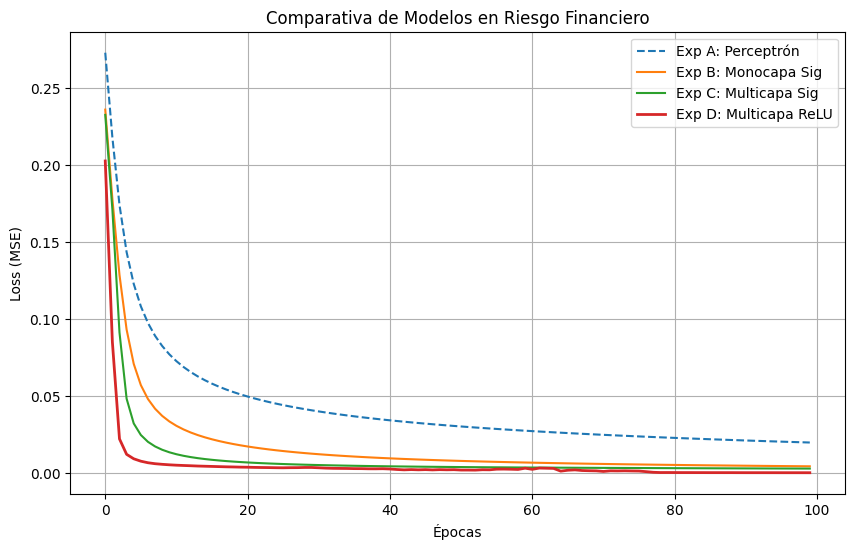


--- RESUMEN FINAL ---

Precisión A -Perceptrón: 98.50%
Precisión B - Monocapa Sigmoide : 99.50%
Precisión C - Multicapa Sigmoide: 99.00%
Precisión D - Multicapa ReLU: 100.00%


PRUEBA DE CAMPO: CASO DE CLIENTE NUEVO
Probabilidad de éxito: 98.32% | Decisión: APROBADO


In [29]:
# 1. VISUALIZACIÓN GRÄFICA DE EVIDENCIA (Comparativa de Loss)
plt.figure(figsize=(10, 6))
plt.plot(h_perc.history['loss'], label='Exp A: Perceptrón', linestyle='--')
plt.plot(h_mono.history['loss'], label='Exp B: Monocapa Sig')
plt.plot(h_multi_sig.history['loss'], label='Exp C: Multicapa Sig')
plt.plot(h_multi_relu.history['loss'], label='Exp D: Multicapa ReLU', linewidth=2)
plt.title('Comparativa de Modelos en Riesgo Financiero')
plt.ylabel('Loss (MSE)'); plt.xlabel('Épocas'); plt.legend(); plt.grid(True); plt.show()

# Resumen de texto para conclusiones
print("\n--- RESUMEN FINAL ---")
print("\n" + "="*70)
print(f"Precisión A -Perceptrón: {eval_perc[1]*100:.2f}%")
print(f"Precisión B - Monocapa Sigmoide : {eval_mono[1]*100:.2f}%")
print(f"Precisión C - Multicapa Sigmoide: {eval_multi_sig[1]*100:.2f}%")
print(f"Precisión D - Multicapa ReLU: {eval_multi_relu[1]*100:.2f}%")
print("="*70 + "\n")

# 2. PRUEBA DE CAMPO (Inferencia)
print("\nPRUEBA DE CAMPO: CASO DE CLIENTE NUEVO")
nuevo_cliente_s = scaler.transform(np.array([[0.6, 0.3, 0.5, 0.8]]))
prob = m_multi_relu.predict(nuevo_cliente_s, verbose=0)[0][0]
print(f"Probabilidad de éxito: {prob*100:.2f}% | Decisión: {'APROBADO' if prob > 0.5 else 'RECHAZADO'}")


## Conclusiones

 1. ¿Qué cambió al variar la activación?

    Al transicionar de la función Sigmoid a ReLU en las capas ocultas de la arquitectura multicapa, se observó una mejora drástica en la capacidad de aprendizaje del modelo.
    
    Mientras que la activación Sigmoid tiende a presentar saturación de gradientes (haciendo que los pesos se actualicen muy lentamente), ReLU mantiene una respuesta lineal para valores positivos, facilitando un flujo de gradiente más eficiente durante el proceso de backpropagation

2. Comportamiento del Loss y Métricas

    Ahora el grafico muestra que :

  - Convergencia: El modelo con ReLU (Experimento D) logró reducir el error (Loss MSE) mucho más rápido, alcanzando una estabilidad cerca de la época 20.

  - Desempeño: El Perceptrón (Experimento A) y la Monocapa (Experimento B) mostraron limitaciones para capturar la complejidad total del riesgo crediticio. La combinación de una red Multicapa con ReLU entregó la precisión más alta (Accuracy), demostrando que la profundidad requiere funciones de activación modernas para no estancarse.

  - Estabilidad: La curva de pérdida de las activaciones Sigmoid se mantuvo más alta y plana por más tiempo, evidenciando un aprendizaje más costoso computacionalmente.

3. Principales dificultades o hallazgos

  - Hallazgo: Se comprobó que, aunque el problema tiene una base lineal, una arquitectura profunda con la activación adecuada (ReLU) logra generalizar mejor los casos borde del dataset financiero.

  - Dificultad: El principal reto fue asegurar que el escalado de datos (StandardScaler) fuera consistente, ya que sin una normalización previa, las funciones de activación (especialmente Sigmoid) tardaban excesivamente en converger o se quedaban en mínimos locales de error.
